<a href="https://colab.research.google.com/github/hugoportillar22/LLMs/blob/main/HolaMundoLLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
print("hola mundo") # Código generado con GEMINI AI

hola mundo


In [2]:
from transformers import pipeline

In [3]:
classifier = pipeline("sentiment-analysis")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cpu


In [4]:
print(classifier("Flowers are beutiful and they smell delightful"))

[{'label': 'POSITIVE', 'score': 0.9998787641525269}]


In [5]:
print(classifier("I don't like greenhouse gases"))

[{'label': 'NEGATIVE', 'score': 0.9954414367675781}]


# Fine tunning

## Tokenization

In [6]:
import pandas as pd
from datasets import load_dataset #libreria datasets de HuggingFace

In [7]:
data = load_dataset("imdb")
data_train = load_dataset("imdb", split = "train")
data_test = load_dataset("imdb", split="test")

README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

unsupervised-00000-of-00001.parquet:   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [8]:
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [9]:
df = data_test.to_pandas()
display(df.head())

,text,label
0,I love sci-fi and am willing to put up with a ...,0
1,"Worth the entertainment value of a rental, esp...",0
2,its a totally average film with a few semi-alr...,0
3,STAR RATING: ***** Saturday Night **** Friday ...,0
4,"First off let me say, If you haven't enjoyed a...",0


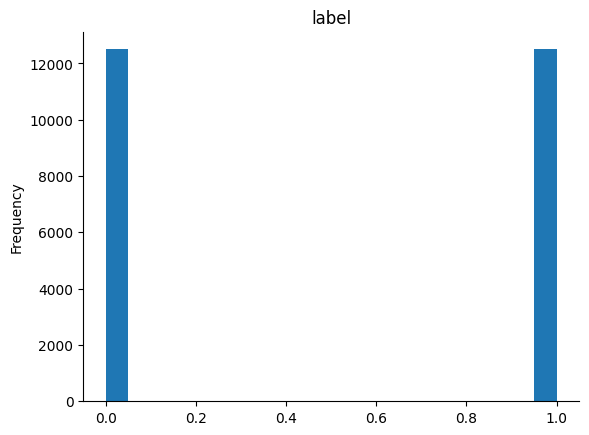

In [10]:
# Sugerido y generado por gemini
from matplotlib import pyplot as plt
df['label'].plot(kind='hist', bins=20, title='label')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [11]:
#Dividimos el dataset en 4 y seleccionamos el trozo (shard) 0 (1/4)
data_train = data_train.shard(num_shards=4, index=0)
data_test = data_test.shard(num_shards=4, index=0)

In [12]:
data_test

Dataset({
    features: ['text', 'label'],
    num_rows: 6250
})

In [13]:
# Cargamos clase que automáticamente elige el tokenizador correcto pal modelo que se indique
# Cargamos clase que carga un modelo preentrenado para tarea de clasificacion de secuencias (sentimiento, clasificador de textos)
from transformers import AutoTokenizer, AutoModelForSequenceClassification

In [14]:
# Descargamos el modelo BERT base (uncased) (tiene 12 capas, 110M parametros y entrenado en inglés sin distinguir MYSC)
# uncased = no distingue mysc ni minusculas, no case sensitive.
# base = base, el básico, pudimos haber usado large..., o cased, o multilingual,
model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased")
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [15]:
# Tokenizamos
def tokenize_function(data_text): #Tokenizamos
    return tokenizer(data_text["text"], # Accedemos a la columna text del dataset
                     return_tensors="pt", # Devuelve tensores en PyTorch (torch.Tensor), podría ser tf, np,darray, none.
                     padding=True, # Rellena los textos más cortos para que tdos midan lo mismo, con padding
                     truncation=True, # Corta los que sean más largos del max_lenght = 64 (multiplos de 64 por arquitectura de GPU)
                     max_length=64) #Limite máximo de tokens por texto



In [24]:
tokenized_training_data = data_train.map(tokenize_function, # Aplica la función a cda fila o batch
                                         batched=True,      # Elegimos que lo aplique a un batch
                                         batch_size=1024)   # Tamaño del batch
# Nuevamente, procesa en paralelo por la arquitectura en batches multiplos de 32 o 64.
# Batches grandes son más estables y rápidos pero consumen más memoria.
#El tamanio del batch, lo determina la VRAM



In [17]:
data_train

Dataset({
    features: ['text', 'label'],
    num_rows: 6250
})

In [18]:
tokenized_training_data

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 6250
})

In [22]:
df = tokenized_training_data.to_pandas()
display(df.head())

######
# input_ids :  comienzan con una cabeza CLS que resume la categoría
# input_ids : uno por palabra o simbolo ortográfico, por ejemplo 1045 := "I" , 1012 := "."
# attention_mask : mascara ( 1 = token real, 0 = padding)
# token_type_ids : 0/1 para distinguir segmentos (BERT); a menudo todo 0 en clasificación de una sola oración.
####


,text,label,input_ids,token_type_ids,attention_mask
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,"[101, 1045, 12524, 1045, 2572, 8025, 1011, 375...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
1,"""I Am Curious: Yellow"" is a risible and preten...",0,"[101, 1000, 1045, 2572, 8025, 1024, 3756, 1000...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
2,If only to avoid making this type of film in t...,0,"[101, 2065, 2069, 2000, 4468, 2437, 2023, 2828...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,This film was probably inspired by Godard's Ma...,0,"[101, 2023, 2143, 2001, 2763, 4427, 2011, 2643...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,"Oh, brother...after hearing about this ridicul...",0,"[101, 2821, 1010, 2567, 1012, 1012, 1012, 2044...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [20]:
tokenized_test_data = data_test.map(tokenize_function, batched=True)

Map:   0%|          | 0/6250 [00:00<?, ? examples/s]

In [20]:
### PENDIENTES
# Conectar github
# en AWS cargar desde AWS
# cambiar el modelo a uno más ligero y usable como distilBERT
